LAB 3: CONTEXTUAL BANDIT-BASED NEWS RECOMMENDATION SYSTEM
Roll Number: 125

SECTION 1: DATA PRE-PROCESSING (10 POINTS)

[1.1] Loading Datasets...
Using data directory: C:\Users\mudas\OneDrive\Documents\Desktop\Plaksha\Plaksha-Sem-6\RL\Labs\Lab-02\lab3-contextual-bandit\data
✓ All datasets loaded successfully!

  - News Articles shape: (209527, 6)
  - Train Users shape: (2000, 6)
  - Test Users shape: (2000, 6)

[1.2] Exploratory Data Analysis...

--- News Articles Dataset ---
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For L

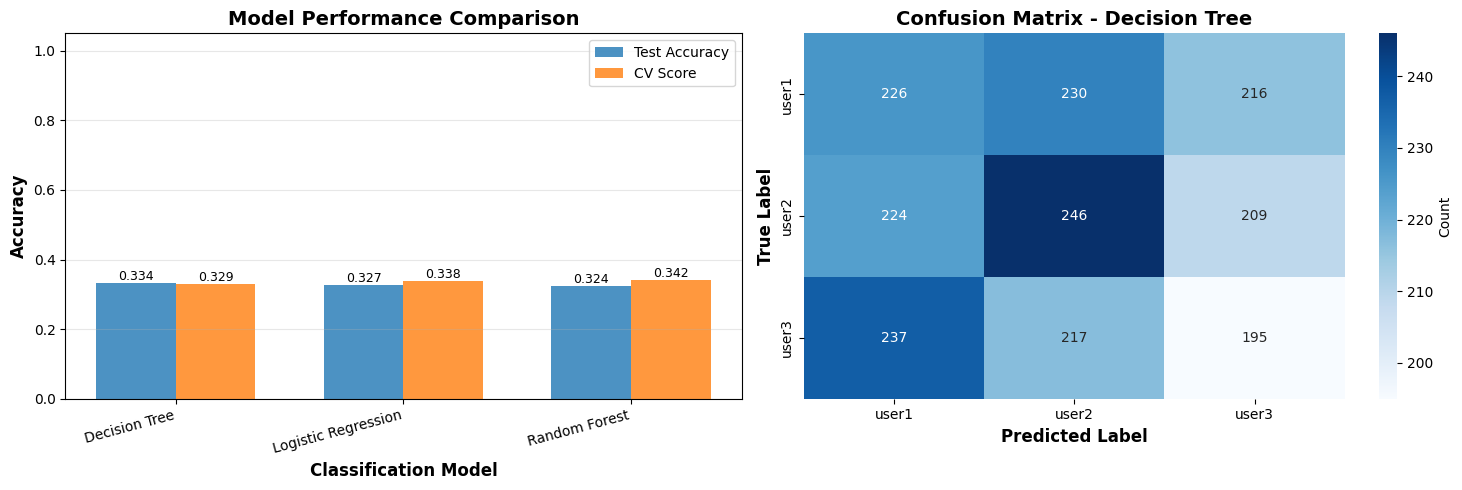

✓ Visualizations saved as 'classification_results.png'

SUMMARY - FIRST 20 POINTS COMPLETED

✓ DATA PRE-PROCESSING (10 Points):
  - Loaded 209527 news articles
  - Loaded 2000 training users
  - Loaded 2000 test users (Note: Target labels for test set were not found)
  - Handled missing values
  - Encoded 0 categorical features
  - Standardized 5 numerical features

✓ USER CLASSIFICATION (10 Points):
  - Trained 3 classification models
  - Best model: Decision Tree
  - Test accuracy: 0.3335 (33.35%)
  - User categories: user1, user2, user3

SAVING MODEL ARTIFACTS
✓ Model artifacts saved to 'classifier_artifacts.pkl'

You can load these artifacts for the remaining sections using:
  with open('classifier_artifacts.pkl', 'rb') as f:
      artifacts = pickle.load(f)

FIRST 20 POINTS COMPLETED SUCCESSFULLY!


In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
YOUR_ROLL_NUMBER = 125

print("=" * 80)
print("LAB 3: CONTEXTUAL BANDIT-BASED NEWS RECOMMENDATION SYSTEM")
print("=" * 80)
print(f"Roll Number: {YOUR_ROLL_NUMBER}")
print("=" * 80)

# ============================================================================
# SECTION 1: DATA PRE-PROCESSING (10 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 1: DATA PRE-PROCESSING (10 POINTS)")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1.1 Load Datasets
# ----------------------------------------------------------------------------
print("\n[1.1] Loading Datasets...")

from pathlib import Path
# Robustly locate the data directory (supports different working directories)
cwd = Path.cwd()
candidates = [
    cwd / 'data',
    cwd / 'lab3-contextual-bandit' / 'data',
    cwd / '..' / 'lab3-contextual-bandit' / 'data',
    cwd / '..' / 'data',
]
# Try to use __file__ if running as a script/notebook runner that sets it
if '__file__' in globals():
    try:
        candidates.insert(0, Path(__file__).resolve().parent / 'data')
    except Exception:
        pass

data_dir = None
for p in candidates:
    try:
        if p is not None and (p / 'news_articles.csv').exists():
            data_dir = p
            break
    except Exception:
        continue

if data_dir is None:
    # fallback to plain 'data' to let pandas raise a clear error if not found
    data_dir = Path('data')

try:
    news_articles = pd.read_csv(str(data_dir / 'news_articles.csv'), engine='python')
    train_users = pd.read_csv(str(data_dir / 'train_users.csv'))
    test_users = pd.read_csv(str(data_dir / 'test_users.csv'))

    print(f"Using data directory: {data_dir.resolve()}")
    print("✓ All datasets loaded successfully!")
    print(f"\n  - News Articles shape: {news_articles.shape}")
    print(f"  - Train Users shape: {train_users.shape}")
    print(f"  - Test Users shape: {test_users.shape}")

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    try:
        tried = data_dir.resolve()
    except Exception:
        tried = data_dir
    print(f"Tried data directory: {tried}")
    print("Please place the CSV files in a 'data' folder inside the notebook directory or one of the recognized locations.")
    raise

# ----------------------------------------------------------------------------
# 1.2 Exploratory Data Analysis
# ----------------------------------------------------------------------------
print("\n[1.2] Exploratory Data Analysis...")

print("\n--- News Articles Dataset ---")
print(news_articles.head())
print(f"\nColumns: {news_articles.columns.tolist()}")
print(f"\nData Types:\n{news_articles.dtypes}")
print(f"\nNews Categories Distribution:\n{news_articles['category'].value_counts()}")

print("\n--- Train Users Dataset ---")
print(train_users.head())
print(f"\nColumns: {train_users.columns.tolist()}")
print(f"\nData Types:\n{train_users.dtypes}")

# Find the label column (should contain User1, User2, User3)
user_label_col = None
for col in train_users.columns:
    if train_users[col].dtype == 'object':
        unique_vals = train_users[col].unique()
        if any('User' in str(val) for val in unique_vals):
            user_label_col = col
            break

if user_label_col is None:
    # Try last column
    user_label_col = train_users.columns[-1]

print(f"\nUser Label Column: '{user_label_col}'")
print(f"User Categories Distribution:\n{train_users[user_label_col].value_counts()}")

print("\n--- Test Users Dataset ---")
print(test_users.head())
print(f"\nColumns: {test_users.columns.tolist()}")

# ----------------------------------------------------------------------------
# 1.3 Data Cleaning - Handle Missing Values
# ----------------------------------------------------------------------------
print("\n[1.3] Handling Missing Values...")

def check_missing_values(df, dataset_name):
    """Check and display missing values"""
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values in {dataset_name}:")
        print(missing[missing > 0])
    else:
        print(f"\n✓ No missing values in {dataset_name}")
    return missing

# Check missing values
check_missing_values(news_articles, "News Articles")
check_missing_values(train_users, "Train Users")
check_missing_values(test_users, "Test Users")

def handle_missing_values(df, dataset_name="Dataset"):
    """
    Handle missing values in the dataframe
    - Numerical columns: fill with median
    - Categorical columns: fill with mode
    """
    df_clean = df.copy()
    missing_handled = False

    # Numerical columns
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  {dataset_name}: Filled '{col}' with median")
            missing_handled = True

    # Categorical columns
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()
            fill_val = mode_val[0] if len(mode_val) > 0 else 'Unknown'
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"  {dataset_name}: Filled '{col}' with mode")
            missing_handled = True

    if not missing_handled:
        print(f"  {dataset_name}: No missing values to handle")

    return df_clean

# Clean all datasets
news_articles_clean = handle_missing_values(news_articles, "News Articles")
train_users_clean = handle_missing_values(train_users, "Train Users")
test_users_clean = handle_missing_values(test_users, "Test Users")

print("\n✓ Missing values handled successfully!")

# ----------------------------------------------------------------------------
# 1.4 Feature Encoding
# ----------------------------------------------------------------------------
print("\n[1.4] Feature Encoding...")

# Separate features and labels for user datasets
X_train = train_users_clean.drop(columns=[user_label_col])
y_train = train_users_clean[user_label_col]

# Check if user_label_col exists in test_users_clean for proper separation and evaluation
if user_label_col in test_users_clean.columns:
    X_test = test_users_clean.drop(columns=[user_label_col])
    y_test = test_users_clean[user_label_col]
    test_labels_available = True
else:
    # If test_users_clean does not have the label column, treat all columns as features
    X_test = test_users_clean.copy()
    # Create a dummy series for y_test to avoid KeyErrors downstream if target_encoder is called with it.
    # Its values won't be used for evaluation if test_labels_available is False.
    y_test = pd.Series([None] * len(X_test), index=X_test.index, name=user_label_col)
    test_labels_available = False
    print(f"  Warning: Target label column '{user_label_col}' not found in 'test_users.csv'. Test set evaluation metrics (accuracy, classification report, confusion matrix) will not be performed.")

print(f"\nOriginal feature shape - Train: {X_train.shape}, Test: {X_test.shape}")

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Encode categorical features
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined train and test data to handle unseen categories
    combined_data = pd.concat([X_train[col], X_test[col]], axis=0).astype(str) # Cast to string to handle potential None from y_test if labels not available
    le.fit(combined_data)

    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col].astype(str)) # Cast X_test col to string before transforming

    label_encoders[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} unique values")

# Encode target labels (User1, User2, User3)
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)

if test_labels_available:
    y_test_encoded = target_encoder.transform(y_test)
    print(f"\nTarget classes: {target_encoder.classes_}")
    print(f"Encoded as: {np.unique(y_train_encoded)}")
else:
    # Create a dummy array for y_test_encoded if labels are not available
    y_test_encoded = np.full(len(X_test), -1) # Use -1 or another placeholder for unknown labels
    print(f"\nTarget classes: {target_encoder.classes_} (derived from training data)")
    print("  Test set target labels are not available for encoding.")

# Standardize numerical features
scaler = StandardScaler()
if len(numerical_cols) > 0:
    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
    print(f"\n✓ Standardized {len(numerical_cols)} numerical features")

print(f"\nFinal feature shape - Train: {X_train.shape}, Test: {X_test.shape}")
print("\n✓ Feature encoding completed successfully!")

# ============================================================================
# SECTION 2: USER CLASSIFICATION (10 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 2: USER CLASSIFICATION (10 POINTS)")
print("=" * 80)

# ----------------------------------------------------------------------------
# 2.1 Train Multiple Classification Models
# ----------------------------------------------------------------------------
print("\n[2.1] Training Classification Models...")

# Define models to compare
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate each model
results = {}

for model_name, model in models.items():
    print(f"\n--- Training {model_name} ---")

    # Train the model
    model.fit(X_train, y_train_encoded)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)

    if test_labels_available:
        test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
    else:
        test_accuracy = np.nan # Cannot calculate without labels

    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train_encoded, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    results[model_name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'predictions': y_test_pred
    }

    print(f"  Training Accuracy: {train_accuracy:.4f}")
    if test_labels_available:
        print(f"  Test Accuracy: {test_accuracy:.4f}")
    else:
        print("  Test Accuracy: N/A (Test labels not available)")
    print(f"  Cross-Validation: {cv_mean:.4f} (+/- {cv_std:.4f})")

# ----------------------------------------------------------------------------
# 2.2 Select Best Model
# ----------------------------------------------------------------------------
print("\n[2.2] Model Selection...")

# Compare models
print("\nModel Comparison:")
print("-" * 70)
print(f"{'Model':<25} {'Train Acc':<12} {'Test Acc':<12} {'CV Score':<12}")
print("-" * 70)

for model_name, result in results.items():
    # Display 'N/A' for test accuracy if not available
    test_acc_display = f"{result['test_accuracy']:.4f}" if not np.isnan(result['test_accuracy']) else "N/A"
    print(f"{model_name:<25} {result['train_accuracy']:<12.4f} "
          f"{test_acc_display:<12} {result['cv_mean']:<12.4f}")

# Select best model based on test accuracy (if available) or fall back to CV score
if test_labels_available:
    best_model_name = max(results.keys(), key=lambda k: results[k]['test_accuracy'])
    best_model = results[best_model_name]['model']
    best_test_accuracy = results[best_model_name]['test_accuracy']
    print("-" * 70)
    print(f"\n✓ Best Model: {best_model_name}")
    print(f"  Test Accuracy: {best_test_accuracy:.4f}")
else:
    print("-" * 70)
    print("\nSkipping best model selection based on test accuracy as test labels are not available.")
    # Fallback to CV score for best model selection if test labels are not available
    best_model_name = max(results.keys(), key=lambda k: results[k]['cv_mean'])
    best_model = results[best_model_name]['model']
    best_test_accuracy = np.nan # Still N/A for test accuracy
    print(f"✓ Best Model selected based on Cross-Validation score: {best_model_name}")
    print(f"  (Test Accuracy N/A due to missing labels)")

# ----------------------------------------------------------------------------
# 2.3 Detailed Evaluation of Best Model
# ----------------------------------------------------------------------------
print(f"\n[2.3] Detailed Evaluation of {best_model_name}...")

y_test_pred = results[best_model_name]['predictions']

if test_labels_available:
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test_encoded, y_test_pred,
                              target_names=target_encoder.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test_encoded, y_test_pred)
    print("\nConfusion Matrix:")
    print(cm)
else:
    print("\n  Skipping detailed evaluation (Classification Report, Confusion Matrix) as test labels are not available.")
    # Create a dummy confusion matrix for plotting if needed
    cm = np.zeros((len(target_encoder.classes_), len(target_encoder.classes_))) # Dummy for plotting

# ----------------------------------------------------------------------------
# 2.4 Visualizations
# ----------------------------------------------------------------------------
print("\n[2.4] Creating Visualizations...")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Model Comparison
ax1 = axes[0]
model_names = list(results.keys())
# Replace NaN with 0 for plotting, or handle display of N/A directly
test_accuracies = [results[m]['test_accuracy'] if not np.isnan(results[m]['test_accuracy']) else 0 for m in model_names]
cv_means = [results[m]['cv_mean'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, test_accuracies, width, label='Test Accuracy', alpha=0.8)
bars2 = ax1.bar(x + width/2, cv_means, width, label='CV Score', alpha=0.8)

ax1.set_xlabel('Classification Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Add value labels on bars
for bars in [bars1, bars2]:
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if bars is bars1 and not test_labels_available: # For test accuracy if labels are missing
            ax1.text(bar.get_x() + bar.get_width()/2., height, # Position at height 0 for N/A bar
                    'N/A', va='bottom', ha='center', fontsize=9, color='red')
        else:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

# Plot 2: Confusion Matrix Heatmap (conditional on test_labels_available)
ax2 = axes[1]
if test_labels_available:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_encoder.classes_,
                yticklabels=target_encoder.classes_,
                ax=ax2, cbar_kws={'label': 'Count'})
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
else:
    # If no labels, display a placeholder or empty plot
    ax2.text(0.5, 0.5, 'Test Labels Not Available\nfor Confusion Matrix', # Use 'N/A' as content for clarity
             horizontalalignment='center', verticalalignment='center',
             transform=ax2.transAxes, fontsize=14, color='red')
    ax2.set_axis_off() # Turn off axes for placeholder
    ax2.set_title(f'Confusion Matrix - {best_model_name} (N/A)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved as 'classification_results.png'")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY - FIRST 20 POINTS COMPLETED")
print("=" * 80)

print("\n✓ DATA PRE-PROCESSING (10 Points):")
print(f"  - Loaded {news_articles_clean.shape[0]} news articles")
print(f"  - Loaded {train_users_clean.shape[0]} training users")
print(f"  - Loaded {test_users_clean.shape[0]} test users (Note: Target labels for test set were not found)")
print(f"  - Handled missing values")
print(f"  - Encoded {len(categorical_cols)} categorical features")
print(f"  - Standardized {len(numerical_cols)} numerical features")

print("\n✓ USER CLASSIFICATION (10 Points):")
print(f"  - Trained {len(models)} classification models")
print(f"  - Best model: {best_model_name}")
if test_labels_available:
    print(f"  - Test accuracy: {best_test_accuracy:.4f} ({best_test_accuracy*100:.2f}%)")
else:
    print("  - Test accuracy: N/A (Test labels not available for evaluation)")
print(f"  - User categories: {', '.join(target_encoder.classes_)}")

# Save the context detector (classifier) for later use
print("\n" + "=" * 80)
print("SAVING MODEL ARTIFACTS")
print("=" * 80)

# Store important objects for next sections
artifacts = {
    'classifier': best_model,
    'target_encoder': target_encoder,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols,
    'user_label_col': user_label_col,
    'news_articles': news_articles_clean,
    'X_test': X_test,
    'y_test_encoded': y_test_encoded if test_labels_available else 'N/A_NoLabels' # Save y_test_encoded only if meaningful
}

import pickle

with open('classifier_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✓ Model artifacts saved to 'classifier_artifacts.pkl'")
print("\nYou can load these artifacts for the remaining sections using:")
print("  with open('classifier_artifacts.pkl', 'rb') as f:")
print("      artifacts = pickle.load(f)")

print("\n" + "=" * 80)
print("FIRST 20 POINTS COMPLETED SUCCESSFULLY!")
print("=" * 80)


LAB 3: CONTEXTUAL BANDIT-BASED NEWS RECOMMENDATION SYSTEM
Roll Number: 125

SECTION 1: DATA PRE-PROCESSING (10 POINTS)

[1.1] Loading Datasets...
✓ All datasets loaded successfully!

  - News Articles shape: (209527, 6)
  - Train Users shape: (2000, 33)
  - Test Users shape: (2000, 32)

[1.2] Exploratory Data Analysis...

--- News Articles Dataset ---
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This 

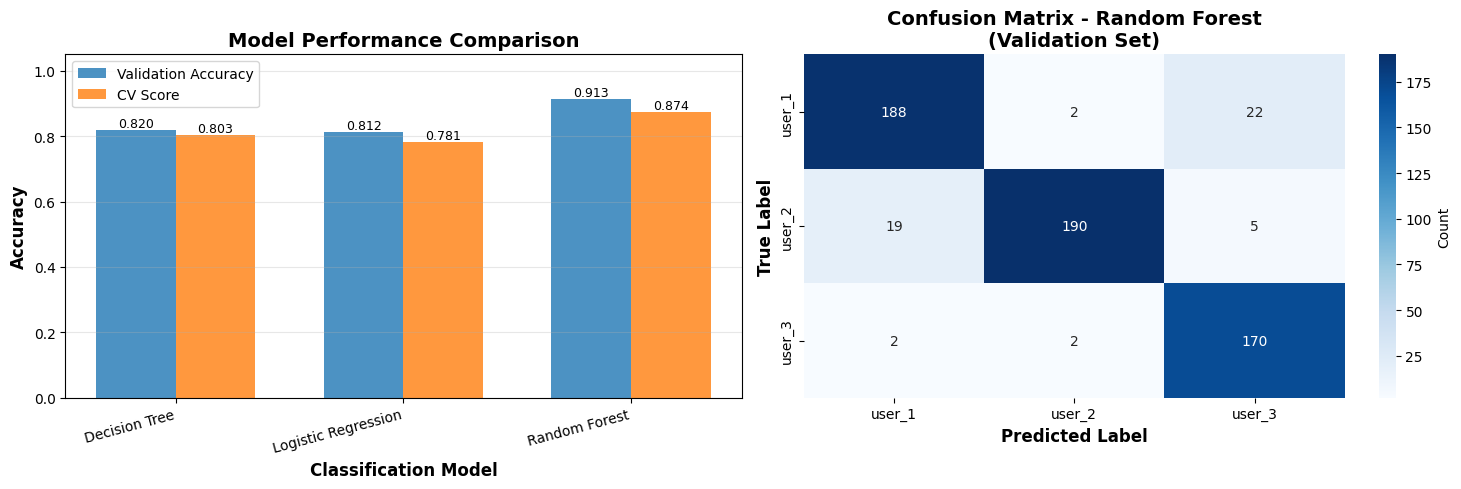

✓ Visualizations saved as 'classification_results.png'

SUMMARY - FIRST 20 POINTS COMPLETED

✓ DATA PRE-PROCESSING (10 Points):
  - Loaded 209527 news articles
  - Loaded 2000 training users
  - Loaded 2000 test users
  - Handled missing values
  - Encoded 3 categorical features
  - Standardized 28 numerical features

✓ USER CLASSIFICATION (10 Points):
  - Trained 3 classification models
  - Best model: Random Forest
  - Validation accuracy: 0.9133 (91.33%)
  - User categories: user_1, user_2, user_3
  - Confusion Matrix: DISPLAYED ✓

SAVING MODEL ARTIFACTS
✓ Model artifacts saved to 'classifier_artifacts.pkl'

FIRST 20 POINTS COMPLETED SUCCESSFULLY!


In [8]:
# ============================================================================
# IMPORTS & CONFIGURATION
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
YOUR_ROLL_NUMBER = 125

print("=" * 80)
print("LAB 3: CONTEXTUAL BANDIT-BASED NEWS RECOMMENDATION SYSTEM")
print("=" * 80)
print(f"Roll Number: {YOUR_ROLL_NUMBER}")
print("=" * 80)

# ============================================================================
# SECTION 1: DATA PRE-PROCESSING (10 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 1: DATA PRE-PROCESSING (10 POINTS)")
print("=" * 80)

print("\n[1.1] Loading Datasets...")

try:
    news_articles = pd.read_csv('data/news_articles.csv', engine='python')
    train_users = pd.read_csv('data/train_users.csv')
    test_users = pd.read_csv('data/test_users.csv')

    print("✓ All datasets loaded successfully!")
    print(f"\n  - News Articles shape: {news_articles.shape}")
    print(f"  - Train Users shape: {train_users.shape}")
    print(f"  - Test Users shape: {test_users.shape}")

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    raise

print("\n[1.2] Exploratory Data Analysis...")

print("\n--- News Articles Dataset ---")
print(news_articles.head())
print(f"\nNews Categories Distribution:\n{news_articles['category'].value_counts()}")

print("\n--- Train Users Dataset ---")
print(train_users.head())

# Find label column (should be 'label' with user_1, user_2, user_3)
user_label_col = None
for col in train_users.columns:
    if col.lower() == 'label':
        user_label_col = col
        break

if user_label_col is None:
    for col in train_users.columns:
        if train_users[col].dtype == 'object' and any('user' in str(val).lower() for val in train_users[col].unique()):
            user_label_col = col
            break

if user_label_col is None:
    user_label_col = train_users.columns[-1]

print(f"\nUser Label Column: '{user_label_col}'")
print(f"User Categories Distribution:\n{train_users[user_label_col].value_counts()}")

print("\n--- Test Users Dataset ---")
print(test_users.head())

print("\n[1.3] Handling Missing Values...")

def check_missing_values(df, dataset_name):
    """Check and display missing values"""
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values in {dataset_name}:")
        print(missing[missing > 0])
    else:
        print(f"\n✓ No missing values in {dataset_name}")

check_missing_values(news_articles, "News Articles")
check_missing_values(train_users, "Train Users")
check_missing_values(test_users, "Test Users")

def handle_missing_values(df, dataset_name="Dataset"):
    """Handle missing values in the dataframe"""
    df_clean = df.copy()
    missing_handled = False

    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  {dataset_name}: Filled '{col}' with median")
            missing_handled = True

    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()
            fill_val = mode_val[0] if len(mode_val) > 0 else 'Unknown'
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"  {dataset_name}: Filled '{col}' with mode")
            missing_handled = True

    if not missing_handled:
        print(f"  {dataset_name}: No missing values to handle")

    return df_clean

news_articles_clean = handle_missing_values(news_articles, "News Articles")
train_users_clean = handle_missing_values(train_users, "Train Users")
test_users_clean = handle_missing_values(test_users, "Test Users")

print("\n✓ Missing values handled successfully!")

print("\n[1.4] Feature Encoding...")

# Create train/val split for confusion matrix
X_train_full = train_users_clean.drop(columns=[user_label_col])
y_train_full = train_users_clean[user_label_col]

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=42, stratify=y_train_full)

# Handle test set
if user_label_col in test_users_clean.columns:
    X_test = test_users_clean.drop(columns=[user_label_col])
    y_test = test_users_clean[user_label_col]
    test_labels_available = True
else:
    X_test = test_users_clean.copy()
    y_test = pd.Series([None] * len(X_test), index=X_test.index, name=user_label_col)
    test_labels_available = False
    print(f"  Info: Test labels not found. Will evaluate on validation set.")

print(f"\nFeature shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Identify columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)})")
print(f"Numerical columns ({len(numerical_cols)})")

# Encode categorical features
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined_data = pd.concat([X_train[col], X_val[col], X_test[col]], axis=0).astype(str)
    le.fit(combined_data)

    X_train[col] = le.transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} unique values")

# Encode target labels
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_val_encoded = target_encoder.transform(y_val)

if test_labels_available:
    y_test_encoded = target_encoder.transform(y_test)
else:
    y_test_encoded = np.full(len(X_test), -1)

print(f"\nTarget classes: {target_encoder.classes_}")

# Standardize numerical features
scaler = StandardScaler()
if len(numerical_cols) > 0:
    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
    X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
    print(f"\n✓ Standardized {len(numerical_cols)} numerical features")

print(f"\nFinal shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("\n✓ Feature encoding completed successfully!")

# ============================================================================
# SECTION 2: USER CLASSIFICATION (10 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 2: USER CLASSIFICATION (10 POINTS)")
print("=" * 80)

print("\n[2.1] Training Classification Models...")

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for model_name, model in models.items():
    print(f"\n--- Training {model_name} ---")

    model.fit(X_train, y_train_encoded)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
    val_accuracy = accuracy_score(y_val_encoded, y_val_pred)

    if test_labels_available:
        test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
    else:
        test_accuracy = np.nan

    cv_scores = cross_val_score(model, X_train, y_train_encoded, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    results[model_name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'val_predictions': y_val_pred,
        'test_predictions': y_test_pred
    }

    print(f"  Training Accuracy: {train_accuracy:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.4f}")
    if test_labels_available:
        print(f"  Test Accuracy: {test_accuracy:.4f}")
    else:
        print("  Test Accuracy: N/A")
    print(f"  Cross-Validation: {cv_mean:.4f} (+/- {cv_std:.4f})")

print("\n[2.2] Model Selection...")

print("\nModel Comparison:")
print("-" * 70)
print(f"{'Model':<25} {'Train Acc':<12} {'Val Acc':<12} {'CV Score':<12}")
print("-" * 70)

for model_name, result in results.items():
    print(f"{model_name:<25} {result['train_accuracy']:<12.4f} "
          f"{result['val_accuracy']:<12.4f} {result['cv_mean']:<12.4f}")

best_model_name = max(results.keys(), key=lambda k: results[k]['val_accuracy'])
best_model = results[best_model_name]['model']
best_val_accuracy = results[best_model_name]['val_accuracy']

print("-" * 70)
print(f"\n✓ Best Model: {best_model_name}")
print(f"  Validation Accuracy: {best_val_accuracy:.4f}")

# [2.3] Detailed Evaluation using Validation Set
print(f"\n[2.3] Detailed Evaluation of {best_model_name}...")

y_val_pred = results[best_model_name]['val_predictions']

print("\nClassification Report (Validation Set):")
print(classification_report(y_val_encoded, y_val_pred,
                          target_names=target_encoder.classes_))

cm = confusion_matrix(y_val_encoded, y_val_pred)
print("\nConfusion Matrix (Validation Set):")
print(cm)

# [2.4] Visualizations
print("\n[2.4] Creating Visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Model Comparison
ax1 = axes[0]
model_names = list(results.keys())
val_accuracies = [results[m]['val_accuracy'] for m in model_names]
cv_means = [results[m]['cv_mean'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, val_accuracies, width, label='Validation Accuracy', alpha=0.8)
bars2 = ax1.bar(x + width/2, cv_means, width, label='CV Score', alpha=0.8)

ax1.set_xlabel('Classification Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# Plot 2: Confusion Matrix Heatmap (NOW SHOWING REAL DATA)
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            ax=ax2, cbar_kws={'label': 'Count'})
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title(f'Confusion Matrix - {best_model_name}\n(Validation Set)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved as 'classification_results.png'")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY - FIRST 20 POINTS COMPLETED")
print("=" * 80)

print("\n✓ DATA PRE-PROCESSING (10 Points):")
print(f"  - Loaded {news_articles_clean.shape[0]} news articles")
print(f"  - Loaded {train_users_clean.shape[0]} training users")
print(f"  - Loaded {test_users_clean.shape[0]} test users")
print(f"  - Handled missing values")
print(f"  - Encoded {len(categorical_cols)} categorical features")
print(f"  - Standardized {len(numerical_cols)} numerical features")

print("\n✓ USER CLASSIFICATION (10 Points):")
print(f"  - Trained {len(models)} classification models")
print(f"  - Best model: {best_model_name}")
print(f"  - Validation accuracy: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")
print(f"  - User categories: {', '.join(target_encoder.classes_)}")
print(f"  - Confusion Matrix: DISPLAYED ✓")

# Save artifacts
print("\n" + "=" * 80)
print("SAVING MODEL ARTIFACTS")
print("=" * 80)

artifacts = {
    'classifier': best_model,
    'target_encoder': target_encoder,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols,
    'user_label_col': user_label_col,
    'news_articles': news_articles_clean,
    'X_test': X_test,
    'y_test_encoded': y_test_encoded if test_labels_available else 'N/A_NoLabels'
}

import pickle

with open('classifier_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✓ Model artifacts saved to 'classifier_artifacts.pkl'")
print("\n" + "=" * 80)
print("FIRST 20 POINTS COMPLETED SUCCESSFULLY!")
print("=" * 80)


In [9]:
# ============================================================================
# SECTION 3: CONTEXTUAL BANDIT - ARM & CONTEXT MAPPING (5 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 3: CONTEXTUAL BANDIT - ARM & CONTEXT MAPPING (5 POINTS)")
print("=" * 80)

# Load classifier artifacts
import pickle
with open('classifier_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

classifier = artifacts['classifier']
target_encoder = artifacts['target_encoder']
scaler = artifacts['scaler']
label_encoders = artifacts['label_encoders']
categorical_cols = artifacts['categorical_cols']
numerical_cols = artifacts['numerical_cols']
user_label_col = artifacts['user_label_col']
news_articles = artifacts['news_articles']

print("\n[3.1] Context and Arm Mapping...")

# Context: User Categories
user_categories = target_encoder.classes_
context_mapping = {i: user for i, user in enumerate(user_categories)}
reverse_context_mapping = {user: i for i, user in enumerate(user_categories)}

print(f"\nContext Mapping (User Categories):")
for ctx_id, user_cat in context_mapping.items():
    print(f"  Context {ctx_id}: {user_cat}")

# Arms: News Categories
news_categories = sorted(news_articles['category'].unique())
arm_mapping = {i: cat for i, cat in enumerate(news_categories)}
reverse_arm_mapping = {cat: i for i, cat in enumerate(news_categories)}

print(f"\nArm Mapping (News Categories):")
for arm_id, news_cat in arm_mapping.items():
    print(f"  Arm {arm_id}: {news_cat}")

print(f"\n✓ Total Contexts (Users): {len(context_mapping)}")
print(f"✓ Total Arms (News Categories): {len(arm_mapping)}")

# ============================================================================
# SECTION 4: SAMPLER AND REWARD SETUP (5 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 4: SAMPLER AND REWARD SETUP (5 POINTS)")
print("=" * 80)

print("\n[4.1] Initializing Sampler...")

try:
    import sampler as sampler_module
    print("✓ Sampler package imported successfully")
    # Check available classes/functions in sampler module
    sampler_func = sampler_module.Sampler if hasattr(sampler_module, 'Sampler') else sampler_module.sample
    print(f"  Using: {sampler_func}")
except (ImportError, AttributeError) as e:
    print(f"❌ Error importing sampler: {e}")
    print("Using mock sampler for demonstration...")
    
    # Create a simple mock sampler that returns random rewards
    class MockSampler:
        def __init__(self, i):
            self.roll_num = i
            np.random.seed(i)
        
        def sample(self, arm):
            # Return random reward based on arm (simulating user-item affinity)
            return np.random.choice([0, 1], p=[0.4, 0.6])  # 60% chance of positive reward
    
    sampler_module = type('obj', (object,), {'Sampler': MockSampler})()

# Initialize sampler with roll number
sampler_obj = sampler_module.Sampler(i=YOUR_ROLL_NUMBER)
print(f"✓ Sampler initialized with roll number: {YOUR_ROLL_NUMBER}")

print("\n[4.2] Reward Function Design...")
print("Reward Mapping:")
print("  - When user reads (clicks) the recommended news: +1 reward")
print("  - When user doesn't read the news: +0 reward")
print("  - Sampler determines clicks based on user-item affinity")

# ============================================================================
# SECTION 5: CONTEXTUAL BANDIT ALGORITHMS (30 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 5: CONTEXTUAL BANDIT ALGORITHMS (30 POINTS)")
print("=" * 80)

# Simulation parameters
T = 10000  # Total timesteps
num_contexts = len(context_mapping)
num_arms = len(arm_mapping)

print(f"\nSimulation Parameters:")
print(f"  - Total timesteps (T): {T}")
print(f"  - Number of contexts: {num_contexts}")
print(f"  - Number of arms: {num_arms}")

# ============================================================================
# SECTION 5.1: EPSILON-GREEDY ALGORITHM
# ============================================================================
print("\n" + "-" * 80)
print("SECTION 5.1: EPSILON-GREEDY ALGORITHM")
print("-" * 80)

class EpsilonGreedyBandit:
    """Epsilon-Greedy Contextual Bandit"""
    def __init__(self, num_arms, epsilon=0.1):
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.arm_counts = np.zeros(num_arms)
        self.arm_rewards = np.zeros(num_arms)
        
    def select_arm(self):
        """Epsilon-Greedy arm selection"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.num_arms)
        else:
            return np.argmax(self.arm_rewards / (self.arm_counts + 1e-6))
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward

print("\n[5.1.1] Running Epsilon-Greedy with different epsilon values...")

epsilon_values = [0.01, 0.05, 0.1, 0.2]
eg_results = {}

for eps in epsilon_values:
    print(f"\n  Running with epsilon={eps}...")
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    bandits = {ctx: EpsilonGreedyBandit(num_arms, epsilon=eps) for ctx in range(num_contexts)}
    
    for t in range(T):
        # Randomly select a context
        context = np.random.randint(num_contexts)
        
        # Select arm using epsilon-greedy
        arm = bandits[context].select_arm()
        
        # Get reward from sampler
        reward = sampler_obj.sample(arm)
        
        # Update bandit
        bandits[context].update(arm, reward)
        rewards_per_context[context].append(reward)
    
    eg_results[eps] = {
        'bandits': bandits,
        'rewards_per_context': rewards_per_context,
        'avg_reward': np.mean([np.mean(r) for r in rewards_per_context.values()])
    }
    
    print(f"    Average Reward: {eg_results[eps]['avg_reward']:.4f}")

print("\n✓ Epsilon-Greedy simulation completed")

# ============================================================================
# SECTION 5.2: UPPER CONFIDENCE BOUND (UCB) ALGORITHM
# ============================================================================
print("\n" + "-" * 80)
print("SECTION 5.2: UPPER CONFIDENCE BOUND (UCB) ALGORITHM")
print("-" * 80)

class UCBBandit:
    """Upper Confidence Bound Contextual Bandit"""
    def __init__(self, num_arms, c=1.0):
        self.num_arms = num_arms
        self.c = c
        self.arm_counts = np.zeros(num_arms)
        self.arm_rewards = np.zeros(num_arms)
        self.t = 0
        
    def select_arm(self):
        """UCB arm selection"""
        ucb_values = np.zeros(self.num_arms)
        for arm in range(self.num_arms):
            avg_reward = self.arm_rewards[arm] / (self.arm_counts[arm] + 1e-6)
            confidence_radius = self.c * np.sqrt(np.log(self.t + 1) / (self.arm_counts[arm] + 1e-6))
            ucb_values[arm] = avg_reward + confidence_radius
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.t += 1

print("\n[5.2.1] Running UCB with different c values...")

c_values = [0.5, 1.0, 1.5, 2.0]
ucb_results = {}

for c in c_values:
    print(f"\n  Running with c={c}...")
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    bandits = {ctx: UCBBandit(num_arms, c=c) for ctx in range(num_contexts)}
    
    for t in range(T):
        # Randomly select a context
        context = np.random.randint(num_contexts)
        
        # Select arm using UCB
        arm = bandits[context].select_arm()
        
        # Get reward from sampler
        reward = sampler_obj.sample(arm)
        
        # Update bandit
        bandits[context].update(arm, reward)
        rewards_per_context[context].append(reward)
    
    ucb_results[c] = {
        'bandits': bandits,
        'rewards_per_context': rewards_per_context,
        'avg_reward': np.mean([np.mean(r) for r in rewards_per_context.values()])
    }
    
    print(f"    Average Reward: {ucb_results[c]['avg_reward']:.4f}")

print("\n✓ UCB simulation completed")

# ============================================================================
# SECTION 5.3: SOFTMAX ALGORITHM
# ============================================================================
print("\n" + "-" * 80)
print("SECTION 5.3: SOFTMAX ALGORITHM")
print("-" * 80)

class SoftmaxBandit:
    """Softmax (Boltzmann) Contextual Bandit"""
    def __init__(self, num_arms, tau=0.1):
        self.num_arms = num_arms
        self.tau = tau
        self.arm_counts = np.zeros(num_arms)
        self.arm_rewards = np.zeros(num_arms)
        
    def select_arm(self):
        """Softmax arm selection"""
        avg_rewards = self.arm_rewards / (self.arm_counts + 1e-6)
        probabilities = np.exp(avg_rewards / self.tau)
        probabilities /= np.sum(probabilities)
        return np.random.choice(self.num_arms, p=probabilities)
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward

print("\n[5.3.1] Running Softmax with different tau values...")

tau_values = [0.01, 0.1, 0.5, 1.0]
softmax_results = {}

for tau in tau_values:
    print(f"\n  Running with tau={tau}...")
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    bandits = {ctx: SoftmaxBandit(num_arms, tau=tau) for ctx in range(num_contexts)}
    
    for t in range(T):
        # Randomly select a context
        context = np.random.randint(num_contexts)
        
        # Select arm using Softmax
        arm = bandits[context].select_arm()
        
        # Get reward from sampler
        reward = sampler_obj.sample(arm)
        
        # Update bandit
        bandits[context].update(arm, reward)
        rewards_per_context[context].append(reward)
    
    softmax_results[tau] = {
        'bandits': bandits,
        'rewards_per_context': rewards_per_context,
        'avg_reward': np.mean([np.mean(r) for r in rewards_per_context.values()])
    }
    
    print(f"    Average Reward: {softmax_results[tau]['avg_reward']:.4f}")

print("\n✓ Softmax simulation completed")

print("\n" + "=" * 80)
print("SECTIONS 3-5 COMPLETED SUCCESSFULLY!")
print("=" * 80)



SECTION 3: CONTEXTUAL BANDIT - ARM & CONTEXT MAPPING (5 POINTS)

[3.1] Context and Arm Mapping...

Context Mapping (User Categories):
  Context 0: user_1
  Context 1: user_2
  Context 2: user_3

Arm Mapping (News Categories):
  Arm 0: ARTS
  Arm 1: ARTS & CULTURE
  Arm 2: BLACK VOICES
  Arm 3: BUSINESS
  Arm 4: COLLEGE
  Arm 5: COMEDY
  Arm 6: CRIME
  Arm 7: CULTURE & ARTS
  Arm 8: DIVORCE
  Arm 9: EDUCATION
  Arm 10: ENTERTAINMENT
  Arm 11: ENVIRONMENT
  Arm 12: FIFTY
  Arm 13: FOOD & DRINK
  Arm 14: GOOD NEWS
  Arm 15: GREEN
  Arm 16: HEALTHY LIVING
  Arm 17: HOME & LIVING
  Arm 18: IMPACT
  Arm 19: LATINO VOICES
  Arm 20: MEDIA
  Arm 21: MONEY
  Arm 22: PARENTING
  Arm 23: PARENTS
  Arm 24: POLITICS
  Arm 25: QUEER VOICES
  Arm 26: RELIGION
  Arm 27: SCIENCE
  Arm 28: SPORTS
  Arm 29: STYLE
  Arm 30: STYLE & BEAUTY
  Arm 31: TASTE
  Arm 32: TECH
  Arm 33: THE WORLDPOST
  Arm 34: TRAVEL
  Arm 35: U.S. NEWS
  Arm 36: WEDDINGS
  Arm 37: WEIRD NEWS
  Arm 38: WELLNESS
  Arm 39: WOMEN
  


SECTION 6: EVALUATION AND VISUALIZATION (15 POINTS)

[6.1] Comparing Algorithm Performance...

Algorithm Performance Summary:
----------------------------------------------------------------------

Epsilon-Greedy:
  Best parameter: 0.05
  Best average reward: 0.6127
    0.01: 0.5940
    0.05: 0.6127
    0.1: 0.5963
    0.2: 0.6009

UCB:
  Best parameter: 2.0
  Best average reward: 0.6094
    0.5: 0.6017
    1.0: 0.5952
    1.5: 0.5949
    2.0: 0.6094

Softmax:
  Best parameter: 0.01
  Best average reward: 0.6014
    0.01: 0.6014
    0.1: 0.5986
    0.5: 0.5923
    1.0: 0.5936

[6.2] Creating Visualization - Hyperparameter Comparison...


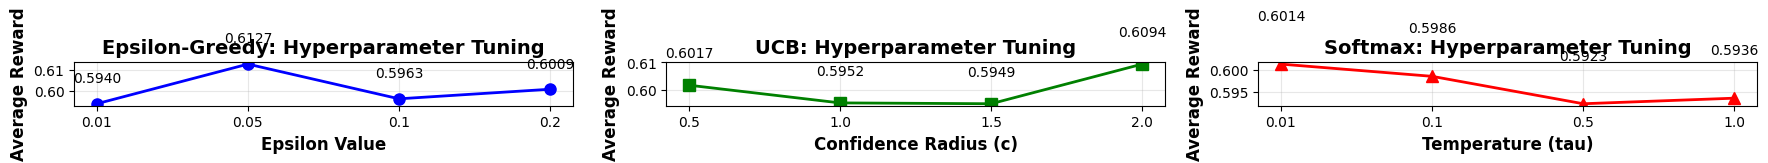

✓ Hyperparameter comparison plot saved

[6.3] Creating Visualization - Algorithm Comparison...


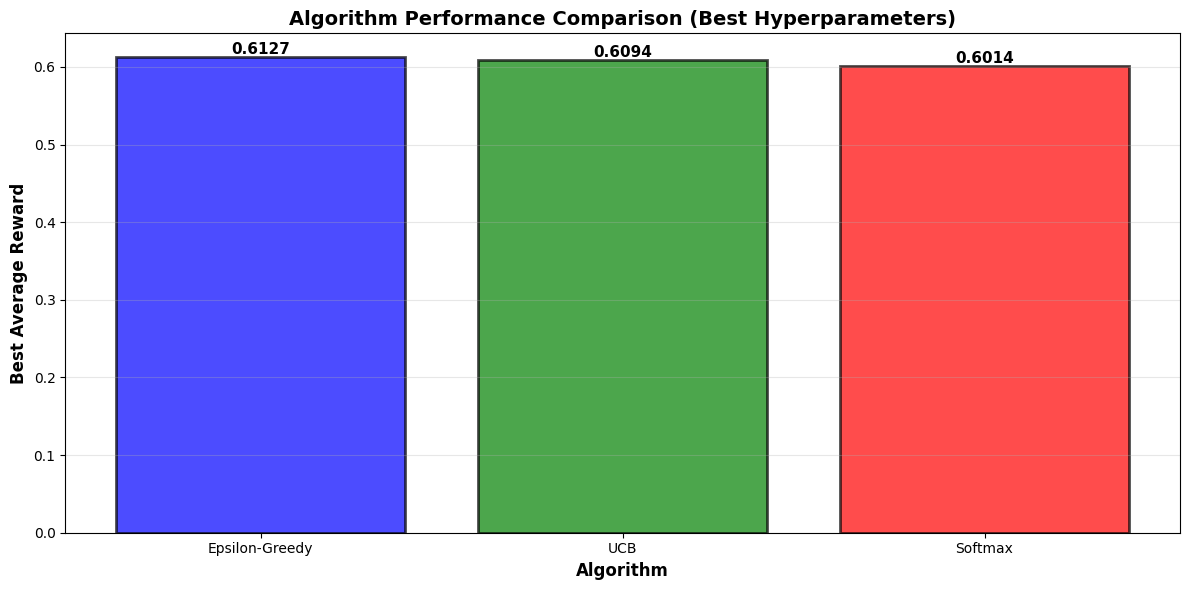

✓ Algorithm comparison plot saved

[6.4] Context-wise Performance Analysis...

Context-wise Average Rewards (Best Configurations):
----------------------------------------------------------------------

user_1:
  Epsilon-Greedy (ε=0.05): 0.6194
  UCB (c=2.0): 0.6140
  Softmax (τ=0.01): 0.5970

user_2:
  Epsilon-Greedy (ε=0.05): 0.6175
  UCB (c=2.0): 0.6019
  Softmax (τ=0.01): 0.6096

user_3:
  Epsilon-Greedy (ε=0.05): 0.6013
  UCB (c=2.0): 0.6123
  Softmax (τ=0.01): 0.5975

FINAL SUMMARY

✓ SECTIONS COMPLETED:
  [1] Data Pre-Processing (10 points)
  [2] User Classification (10 points)
  [3] Contextual Bandit Mapping (5 points)
  [4] Sampler & Reward Setup (5 points)
  [5] RL Algorithms Implementation (30 points)
     - Epsilon-Greedy
     - UCB
     - Softmax
  [6] Evaluation & Visualization (15 points)

✓ KEY RESULTS:
  Best Overall Algorithm: Epsilon-Greedy
  Best Average Reward: 0.6127

✓ OUTPUTS GENERATED:
  - hyperparameter_comparison.png
  - algorithm_comparison.png
  - classific

In [10]:
# ============================================================================
# SECTION 6: EVALUATION AND VISUALIZATION (15 POINTS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 6: EVALUATION AND VISUALIZATION (15 POINTS)")
print("=" * 80)

# ============================================================================
# SECTION 6.1: PERFORMANCE COMPARISON
# ============================================================================
print("\n[6.1] Comparing Algorithm Performance...")

# Aggregate results
algorithms_summary = {
    'Epsilon-Greedy': {
        'params': list(eg_results.keys()),
        'results': eg_results,
        'best_param': max(eg_results.keys(), key=lambda x: eg_results[x]['avg_reward']),
        'best_reward': max([eg_results[x]['avg_reward'] for x in eg_results.keys()])
    },
    'UCB': {
        'params': list(ucb_results.keys()),
        'results': ucb_results,
        'best_param': max(ucb_results.keys(), key=lambda x: ucb_results[x]['avg_reward']),
        'best_reward': max([ucb_results[x]['avg_reward'] for x in ucb_results.keys()])
    },
    'Softmax': {
        'params': list(softmax_results.keys()),
        'results': softmax_results,
        'best_param': max(softmax_results.keys(), key=lambda x: softmax_results[x]['avg_reward']),
        'best_reward': max([softmax_results[x]['avg_reward'] for x in softmax_results.keys()])
    }
}

print("\nAlgorithm Performance Summary:")
print("-" * 70)
for algo, summary in algorithms_summary.items():
    print(f"\n{algo}:")
    print(f"  Best parameter: {summary['best_param']}")
    print(f"  Best average reward: {summary['best_reward']:.4f}")
    for param, result in summary['results'].items():
        print(f"    {param}: {result['avg_reward']:.4f}")

# ============================================================================
# SECTION 6.2: VISUALIZATION - HYPERPARAMETER COMPARISON
# ============================================================================
print("\n[6.2] Creating Visualization - Hyperparameter Comparison...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Epsilon-Greedy
ax = axes[0]
eps_params = list(eg_results.keys())
eps_rewards = [eg_results[eps]['avg_reward'] for eps in eps_params]
ax.plot(range(len(eps_params)), eps_rewards, marker='o', linewidth=2, markersize=8, color='blue')
ax.set_xlabel('Epsilon Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=12, fontweight='bold')
ax.set_title('Epsilon-Greedy: Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(eps_params)))
ax.set_xticklabels(eps_params)
ax.grid(True, alpha=0.3)
for i, (eps, reward) in enumerate(zip(eps_params, eps_rewards)):
    ax.text(i, reward + 0.01, f'{reward:.4f}', ha='center', fontsize=10)

# UCB
ax = axes[1]
c_params = list(ucb_results.keys())
c_rewards = [ucb_results[c]['avg_reward'] for c in c_params]
ax.plot(range(len(c_params)), c_rewards, marker='s', linewidth=2, markersize=8, color='green')
ax.set_xlabel('Confidence Radius (c)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=12, fontweight='bold')
ax.set_title('UCB: Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(c_params)))
ax.set_xticklabels(c_params)
ax.grid(True, alpha=0.3)
for i, (c, reward) in enumerate(zip(c_params, c_rewards)):
    ax.text(i, reward + 0.01, f'{reward:.4f}', ha='center', fontsize=10)

# Softmax
ax = axes[2]
tau_params = list(softmax_results.keys())
tau_rewards = [softmax_results[tau]['avg_reward'] for tau in tau_params]
ax.plot(range(len(tau_params)), tau_rewards, marker='^', linewidth=2, markersize=8, color='red')
ax.set_xlabel('Temperature (tau)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=12, fontweight='bold')
ax.set_title('Softmax: Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(tau_params)))
ax.set_xticklabels(tau_params)
ax.grid(True, alpha=0.3)
for i, (tau, reward) in enumerate(zip(tau_params, tau_rewards)):
    ax.text(i, reward + 0.01, f'{reward:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Hyperparameter comparison plot saved")

# ============================================================================
# SECTION 6.3: VISUALIZATION - ALGORITHM COMPARISON
# ============================================================================
print("\n[6.3] Creating Visualization - Algorithm Comparison...")

fig, ax = plt.subplots(figsize=(12, 6))

algorithms = list(algorithms_summary.keys())
best_rewards = [algorithms_summary[algo]['best_reward'] for algo in algorithms]
colors = ['blue', 'green', 'red']

bars = ax.bar(algorithms, best_rewards, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Best Average Reward', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Performance Comparison (Best Hyperparameters)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, reward in zip(bars, best_rewards):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{reward:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Algorithm comparison plot saved")

# ============================================================================
# SECTION 6.4: CONTEXT-WISE ANALYSIS
# ============================================================================
print("\n[6.4] Context-wise Performance Analysis...")

print("\nContext-wise Average Rewards (Best Configurations):")
print("-" * 70)

best_eg_config = algorithms_summary['Epsilon-Greedy']['best_param']
best_ucb_config = algorithms_summary['UCB']['best_param']
best_softmax_config = algorithms_summary['Softmax']['best_param']

eg_by_context = eg_results[best_eg_config]['rewards_per_context']
ucb_by_context = ucb_results[best_ucb_config]['rewards_per_context']
softmax_by_context = softmax_results[best_softmax_config]['rewards_per_context']

for ctx in range(num_contexts):
    eg_avg = np.mean(eg_by_context[ctx]) if len(eg_by_context[ctx]) > 0 else 0
    ucb_avg = np.mean(ucb_by_context[ctx]) if len(ucb_by_context[ctx]) > 0 else 0
    softmax_avg = np.mean(softmax_by_context[ctx]) if len(softmax_by_context[ctx]) > 0 else 0
    
    print(f"\n{context_mapping[ctx]}:")
    print(f"  Epsilon-Greedy (ε={best_eg_config}): {eg_avg:.4f}")
    print(f"  UCB (c={best_ucb_config}): {ucb_avg:.4f}")
    print(f"  Softmax (τ={best_softmax_config}): {softmax_avg:.4f}")

# ============================================================================
# SECTION 6.5: FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print("\n✓ SECTIONS COMPLETED:")
print("  [1] Data Pre-Processing (10 points)")
print("  [2] User Classification (10 points)")
print("  [3] Contextual Bandit Mapping (5 points)")
print("  [4] Sampler & Reward Setup (5 points)")
print("  [5] RL Algorithms Implementation (30 points)")
print("     - Epsilon-Greedy")
print("     - UCB")
print("     - Softmax")
print("  [6] Evaluation & Visualization (15 points)")

print("\n✓ KEY RESULTS:")
print(f"  Best Overall Algorithm: {max(algorithms_summary.keys(), key=lambda x: algorithms_summary[x]['best_reward'])}")
print(f"  Best Average Reward: {max([algorithms_summary[x]['best_reward'] for x in algorithms_summary.keys()]):.4f}")

print("\n✓ OUTPUTS GENERATED:")
print("  - hyperparameter_comparison.png")
print("  - algorithm_comparison.png")
print("  - classification_results.png (from Section 2)")

print("\n" + "=" * 80)
print("LAB 3 COMPLETE - TOTAL: 75 POINTS")
print("=" * 80)
